<a href="https://colab.research.google.com/github/SunMingYang04/CV/blob/main/Modern_Computer_Vision_with_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 第一部分 面向计算机视觉的深度学习基础知识

## 第一章 人工神经网络基础

### 前向传播

In [ ]:
#输入变量值（inputs），weights(如果是第一次迭代则随机初始化)和所提供数据集的实际outputs作为feed_forward的参数
import numpy as np
def feed_forward(inputs,outputs,weights):          #注意权重数组也包含了各节点的偏置项
  pre_hidden=np.dot(inputs,weights[0])+weights[1]      #连接输入层和隐藏层的权重值weights[0],weights[1]是与隐藏层有关的偏置
  hidden=1/(1+np.exp(-pre_hidden))             #对获得的隐藏层值使用sigmoid激活函数
  pred_out=np.dot(hidden,weights[2])+weights[3]       #同上得到输出层值
  mean_squared_error=np.mean(np.square(pred_out-outputs))
  return mean_squared_error

###反向传播

#### 梯度下降

In [ ]:
import numpy as np
from copy import deepcopy
def feed_forward(inputs,outputs,weights):          #注意权重数组也包含了各节点的偏置项
  pre_hidden=np.dot(inputs,weights[0])+weights[1]      #连接输入层和隐藏层的权重值weights[0],weights[1]是与隐藏层有关的偏置
  hidden=1/(1+np.exp(-pre_hidden))             #对获得的隐藏层值使用sigmoid激活函数
  pred_out=np.dot(hidden,weights[2])+weights[3]       #同上得到输出层值
  mean_squared_error=np.mean(np.square(pred_out-outputs))
  return mean_squared_error
#2.权重与偏置增加一个很小的量，并更新计算总体误差损失的平方值
def update_weights(inputs,outputs,weights,lr):
  original_weights=deepcopy(weights)
  tmp_weights=deepcopy(weights)
  updated_weights=deepcopy(weights)
  original_loss=feed_forward(inputs,outputs,weights)
  for i,layer in enumerate(original_weights):
    for index,weight in np.ndenumerate(layer):
      tmp_weights=deepcopy(weights)
      tmp_weights[i][index]+=0.0001
      _loss_plus=feed_forward(inputs,outputs,tmp_weights)
      grad=(_loss_plus-original_loss)/0.0001
      updated_weights[i][index]-=lr*grad
  return updated_weights,original_loss

##常用链式法则，无需每次重新计算前向传播



###整合前向传播与反向传播

In [ ]:
#1.导入包与定义数据集
import numpy as np
from copy import deepcopy
x=np.array([1,1])
y=np.array([0])
#2.初始化权重与偏置
W=[
    np.array([[-0.0053,0.3793],
         [-0.5820,-0.5204],
         [-0.2723,0.1896]],dtype=np.float32).T,
    np.array([-0.0140,0.5670,-0.0628],dtype=np.float32),
    np.array([[0.1528,-0.1745,-0.1135]],dtype=np.float32).T,
    np.array([-0.5516],dtype=np.float32)
]
#3.运行100个epoch
def feed_forward(inputs,outputs,weights):
  pre_hidden=np.dot(inputs,weights[0])+weights[1]
  hidden=1/(1+np.exp(-pre_hidden))
  pred_out=np.dot(hidden,weights[2])+weights[3]
  mean_squared_error=np.mean(np.square(pred_out-outputs))
  return mean_squared_error
def update_weights(inputs,outputs,weights,lr):
  original_weights=deepcopy(weights)
  tmp_weights=deepcopy(weights)
  updated_weights=deepcopy(weights)
  original_loss=feed_forward(inputs,outputs,weights)
  for i,layer in enumerate(original_weights):
    for index,weight in np.ndenumerate(layer):
      tmp_weights=deepcopy(weights)
      tmp_weights[i][index]+=0.0001
      _loss_plus=feed_forward(inputs,outputs,tmp_weights)
      grad=(_loss_plus-original_loss)/(0.0001)
      updated_weights[i][index]-=lr*grad
  return updated_weights,original_loss
losses=[]
for epoch in range(100):
  W,loss=update_weights(x,y,W,0.01)
  losses.append(loss)

import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(losses)
plt.title('Loss over increasing number of epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss value')


## 第二章 Pytorch基础

##Pytorch张量

In [ ]:
#导入Pytorch并初始化张量
import torch
x=torch.tensor([[1,2]])
y=torch.tensor([[1],[2]])
print(x.shape)
print(y.shape)
print(x.dtype)
print(y.dtype)

In [ ]:
#张量内的所有元素数据相同，如果张量内包含不同数据类型，将会转为为最通用的数据类型
x=torch.tensor([False,1,2.0])
print(x)

In [ ]:
#生成张量对象，3x4，填充0
torch.zeros((3,4))

In [ ]:
#填充1
torch.ones((3,4))

In [ ]:
#生成值具有0和1之间（包括小值但不包括大值）
torch.randint(low=0,high=10,size=(3,4))

In [ ]:
#生成[0,1]之间随机数
torch.rand((3,4))

In [ ]:
#生成数值符合正态分布
torch.randn((3,4))

In [ ]:
#可以直接使用torch.tensor(<Numpy-array>)将Numpy数组转换为Torch张量
x=np.array([[10,20,30],[2,3,4]])
y=torch.tensor(x)
print(type(x),type(y))

##张量运算

In [2]:
#将元素乘以10
import torch
x=torch.tensor([[1,2,3,4],[5,6,7,8]])
print(x*10)

tensor([[10, 20, 30, 40],
        [50, 60, 70, 80]])


In [3]:
#将10加入x中的元素，并将张量存储在y中
x=torch.tensor([[1,2,3,4],[5,6,7,8]])
y=x.add(10)
print(y)

tensor([[11, 12, 13, 14],
        [15, 16, 17, 18]])


In [13]:
#重塑张量
y=torch.tensor([2,3,1,0])
print(y,y.shape)
y=y.view(4,1)
print(y,y.shape)

tensor([2, 3, 1, 0]) torch.Size([4])
tensor([[2],
        [3],
        [1],
        [0]]) torch.Size([4, 1])


In [8]:
#使用Squeeze(),提供我们想要移除的指标轴。只适合要删除的轴在该维度中只有一个项
x=torch.randn(10,1,10)
z1=torch.squeeze(x,1)#和np.squeeze()相同
print('Squeeze:\n',x.shape,z1.shape)
z2=x.squeeze(1)
print('Squeeze:\n',x.shape,z2.shape)

Squeeze:
 torch.Size([10, 1, 10]) torch.Size([10, 10])
Squeeze:
 torch.Size([10, 1, 10]) torch.Size([10, 10])


In [11]:
#使用unsqueeze，给矩阵增加一个维度
x=torch.randn(10,10)
print(x.shape)
z1=x.unsqueeze(0)
print(z1.shape)
#使用None进行索引是一种特殊的unsqueeze方式
z2,z3,z4=x[None],x[:,None],x[:,:,None]
print(z2.shape,z3.shape,z4.shape)

torch.Size([10, 10])
torch.Size([1, 10, 10])
torch.Size([1, 10, 10]) torch.Size([10, 1, 10]) torch.Size([10, 10, 1])


In [17]:
#实现两个不同张量的矩阵乘法
x=torch.tensor([[1,2,3,4],[5,6,7,8]])
print(torch.matmul(x,y))
print(x@y)

tensor([[11],
        [35]])
tensor([[11],
        [35]])


###Auto grad

In [4]:
#1.定义一个张量，并指明计算梯度
import torch
x=torch.tensor([[2.,-1.],[1.,1.]],requires_grad=True)
print(x)
out=x.pow(2).sum()
print(out)
out.backward()
print(x.grad)

tensor([[ 2., -1.],
        [ 1.,  1.]], requires_grad=True)
tensor(7., grad_fn=<SumBackward0>)
tensor([[ 4., -2.],
        [ 2.,  2.]])


#### Pytorch的张量较Numpy的ndarrays的优势

In [12]:
import torch
x=torch.rand(1,6400)
y=torch.rand(6400,5000)
#2.定义存贮所创建张量对象的设备：
device='cuda'if torch.cuda.is_available()else'cpu'
#3.将张量注册到设备中
x,y=x.to(device),y.to(device)
#4.执行乘法并计时
%timeit z=(x@y)
x,y=x.cpu(),y.cpu()
%timeit z=(x@y)
import numpy as np
x=np.random.random((1,6400))
y=np.random.random((6400,5000))
%timeit z=np.matmul(x,y)

571 µs ± 414 ns per loop (mean ± std. dev. of 7 runs, 1000 loops each)
9.26 ms ± 50.2 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
19 ms ± 661 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


### 使用PyTorch构建神经网络

Parameter containing:
tensor([[ 0.3643, -0.3121],
        [-0.1371,  0.3319],
        [-0.6657,  0.4241],
        [-0.1455,  0.3597],
        [ 0.0983, -0.0866],
        [ 0.1961,  0.0349],
        [ 0.2583, -0.2756],
        [-0.0516, -0.0637]], requires_grad=True)
Parameter containing:
tensor([ 0.1025, -0.0028,  0.6181,  0.2200, -0.2633, -0.4271, -0.1185, -0.3050],
       requires_grad=True)
Parameter containing:
tensor([[-0.1133,  0.0169,  0.2108,  0.1922, -0.3456,  0.2192,  0.0988,  0.3354]],
       requires_grad=True)
Parameter containing:
tensor([0.2334], requires_grad=True)
tensor(87.6332, grad_fn=<MseLossBackward0>)


RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

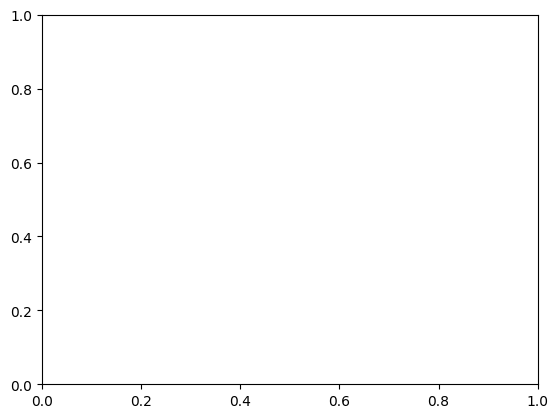

In [1]:
#初始化数据集
#定义输入输出
import torch
x=[[1,2],[3,4],[5,6],[7,8]]
y=[[3],[7],[11],[15]]
#2.转换为张量，如果由GPU就把数据注册到GPU
X=torch.tensor(x).float()
Y=torch.tensor(y).float()
device='cuda'if torch.cuda.is_available()else'cpu'
X=X.to(device)
Y=Y.to(device)
#3.定义神经网络框架
## torch.nn包含有助于构建网络模型的函数：
import torch.nn as nn
## 创建一个类，可以用它构建网络架构，在使用模块创建模型架构时，从nn.Module继承是强制性的，
## 因为他是所有网络模块的基类
class MyNeuralNet(nn.Module):
  ## 在该类中，使用__init__方式初始化神经网络的所有组件。
  ## 必须调用super(),__init__()来确保类继承nn.Module
  def __init__(self):
    super().__init__()
    ## 定义神经网络的层
    self.input_to_hidden_layer=nn.Linear(2,8)
    self.hidden_layer_activation=nn.ReLU()
    self.hidden_to_output_layer=nn.Linear(8,1)
#print(nn.Linear(2,7))
    ## 常见激活函数,sigmoid,softmax,Tanh
  ## 定义了神经网络组件，定义网络前向传播时就可以将这些组件连接起来
  ## 必须使用forward这个函数名，这是因为PyTorch中特殊定义
  def forward(self,x):
    x=self.input_to_hidden_layer(x)
    x=self.hidden_layer_activation(x)
    x=self.hidden_to_output_layer(x)
    return x
## 检查权重值的随机初始化
torch.manual_seed(1)
#4.首先定义MyNeuralNet类对象的一个实例，并注册到device
mynet=MyNeuralNet().to(device)
mynet.input_to_hidden_layer.weight
mynet.parameters()
for par in mynet.parameters():
  print(par)
#5.定义最优化的损失函数
loss_func=nn.MSELoss()
## 其他重要的损失函数有：CrossEntropyLoss，BCELoss
_Y=mynet(X)
loss_value=loss_func(_Y,Y)
print(loss_value)
#6.从torch.optim模块导入SGD，然后将网络对象和学习率作为参数传入
from torch.optim import SGD
opt=SGD(mynet.parameters(),lr=1e-3)

#7.在一轮中一起执行所有要做的步骤
## 计算给定输入和输出所对应的损失值
## 计算每个参数对应的梯度
## 根据每个参数的学习率和梯度更新权重
## 一旦权重被更新，就要确保在下轮计算梯度前更新上一步计算的梯度
opt.zero_grad()
loss_value=loss_func(mynet(X),Y)
loss_value.backward()
opt.step()

loss_history=[]
for _in in range(50):
  opt.zero_grad()
  loss_value=loss_func(mynet(X),Y)
  loss_value.backward()
  opt.step()
  loss_history.append(loss_value)
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss value')
plt.title('Loss variation over increasing epochs')

#### 数据集、数据加载器和批大小

In [14]:
from torch.utils.data import Dataset,DataLoader
import torch
import torch.nn as nn

x=[[1,2],[3,4],[5,6],[7,8]]
y=[[3],[7],[11],[15]]
X=torch.tensor(x).float()
Y=torch.tensor(y).float()
device='cuda'if torch.cuda.is_available()else'cpu'
X=X.to(device)
Y=Y.to(device)

torch.manual_seed(1)
class MyDataset(Dataset):
  def __init__(self,x,y):
    self.x=torch.tensor(x).float()
    self.y=torch.tensor(y).float()
  def __len__(self):
    return len(self.x)
  def __getitem__(self,ix):
    return self.x[ix],self.y[ix]
ds=MyDataset(X,Y)
dl=DataLoader(ds,batch_size=2,shuffle=True)
for x,y in dl:
  print(x,y)

class MyNeuralNet(nn.Module):
  def __init__(self):
    super().__init__()
    ## 定义神经网络的层
    self.input_to_hidden_layer=nn.Linear(2,8)
    self.hidden_layer_activation=nn.ReLU()
    self.hidden_to_output_layer=nn.Linear(8,1)
  def forward(self,x):
    x=self.input_to_hidden_layer(x)
    x=self.hidden_layer_activation(x)
    x=self.hidden_to_output_layer(x)
    return x
mynet=MyNeuralNet().to(device)
loss_func=nn.MSELoss()
from torch.optim import SGD
opt=SGD(mynet.parameters(),lr=1e-3)

import time
history=[]
start=time.time()
for _in in range(50):
  for data in dl:
    x,y=data
    opt.zero_grad()
    loss_value=loss_func(mynet(x),y)
    loss_value.backward()
    opt.step()
    history.append(loss_value)
end=time.time()
print(end-start)

## 预测新的数据点
val_x=[[10,11]]
val_x=torch.tensor(val_x).float().to(device)
mynet(val_x)

tensor([[5., 6.],
        [1., 2.]], device='cuda:0') tensor([[11.],
        [ 3.]], device='cuda:0')
tensor([[3., 4.],
        [7., 8.]], device='cuda:0') tensor([[ 7.],
        [15.]], device='cuda:0')
0.10973715782165527


/tmp/ipykernel_3872/1918015650.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.x=torch.tensor(x).float()
/tmp/ipykernel_3872/1918015650.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y=torch.tensor(y).float()


tensor([[20.7456]], device='cuda:0', grad_fn=<AddmmBackward0>)

#### 实现自定义损失函数

## 第三章 使用Pytorch构建深度神经网络

# 第二部分 物体分类与目标检测

## 第四章 卷积神经网络

### 使用Pytorch构建基于CNN的架构

In [ ]:
#1.导入相关代码库
import torch
from torch import nn
from torch.utils.data import TensorDataset,Dataset,DataLoader
from torch.optim import SGD,Adam
device='cuda' if torch.cuda.is_available() else 'cpu'
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#2.使用以下步骤创建数据集
X_train=torch.tensor([[[[1,2,3,4],[2,3,4,5],[5,6,7,8],[1,3,4,5]]],[[[-1,2,3,-4],[2,-3,4,5],[-5,6,-7,8],[-1,-3,-4,-5]]]]).to(device).float()
X_train/=8  #输入数据除以最大输入值8，将数据取值压缩到[-1,1] and 输入数据是(N,C,H,W)=(2,1,4,4),两个图片，一个通道，然后图像4x4
y_train=torch.tensor([0,1]).to(device).float()

#3.定义模型框架
def get_model():
  model=nn.Sequential(
      nn.Conv2d(in_channels=1,out_channels=16,kernel_size=3),
      nn.MaxPool2d(2),
      nn.ReLU(),
      nn.Flatten(),
      nn.Linear(1,1),
      nn.Sigmoid(),
  ).to(device)
  loss_fn=nn.BCELoss()
  optimizer=Adam(model.parameters(),lr=1e-3)
  return model,loss_fn,optimizer

##第五章 面向图像分类的迁移学习

##第六章 图像分类的实战技术

##第七章 目标检测基础

## 第八章 目标检测进阶

## 第九章 图像分割

## 第十章 目标检测与分割的应用

# 第三部分 图像处理

## 第十一章 自编码器与图像处理

## 第十二章 基于GAN的图像生产

## 第十三章 高级GAN图像处理

#第四部分 计算机视觉与其他技术

## 第十四章 使用小样本进行模型训练

## 第十五章 计算机视觉与NLP

## 第十六章 计算机视觉与强化学习

## 第十七章 模型的实际应用部署

##第十八章 使用OpenCV实用程序进行图像分析